# Bluestock MF — Advanced Analytics
Day 5 deliverable. Covers VaR/CVaR, rolling Sharpe, investor cohorts, SIP continuity, a simple fund recommender, and sector concentration (HHI) across all 40 schemes.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../data/raw"  # adjust if your raw CSVs live elsewhere

fund_master   = pd.read_csv(f"{DATA_DIR}/01_fund_master.csv", parse_dates=["launch_date"])
nav_history   = pd.read_csv(f"{DATA_DIR}/02_nav_history.csv", parse_dates=["date"])
scheme_perf   = pd.read_csv(f"{DATA_DIR}/07_scheme_performance.csv")
transactions  = pd.read_csv(f"{DATA_DIR}/08_investor_transactions.csv", parse_dates=["transaction_date"])
holdings      = pd.read_csv(f"{DATA_DIR}/09_portfolio_holdings.csv")

nav_history = nav_history.sort_values(["amfi_code", "date"])
nav_history["daily_return"] = nav_history.groupby("amfi_code")["nav"].pct_change()

scheme_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
print("Loaded:", fund_master.shape[0], "schemes,", nav_history.shape[0], "NAV rows,",
      transactions.shape[0], "transactions")

Loaded: 40 schemes, 46000 NAV rows, 32778 transactions


## 1. Historical VaR (95%) and CVaR — all 40 schemes
VaR = 5th percentile of the daily return distribution. CVaR = average of returns falling at or below the VaR threshold (the expected loss in the worst 5% of days).

In [11]:
def compute_var_cvar(returns, confidence=0.95):
    returns = returns.dropna()
    if len(returns) < 30:
        return np.nan, np.nan
    var_pct = (1 - confidence) * 100
    var = np.percentile(returns, var_pct)
    cvar = returns[returns <= var].mean()
    return var, cvar

var_cvar_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    var95, cvar95 = compute_var_cvar(grp["daily_return"], 0.95)
    var_cvar_rows.append({
        "amfi_code": code_,
        "scheme_name": scheme_names.get(code_, "Unknown"),
        "VaR_95": var95,
        "CVaR_95": cvar95,
    })

var_cvar_df = pd.DataFrame(var_cvar_rows).sort_values("VaR_95")
var_cvar_df.to_csv("var_cvar_report.csv", index=False)
var_cvar_df.head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


## 2. Rolling 90-Day Sharpe Ratio — 5 key funds
Key funds = top 5 by AUM. Sharpe = (rolling mean excess return / rolling std) × √252, using a ~6% annual risk-free rate.

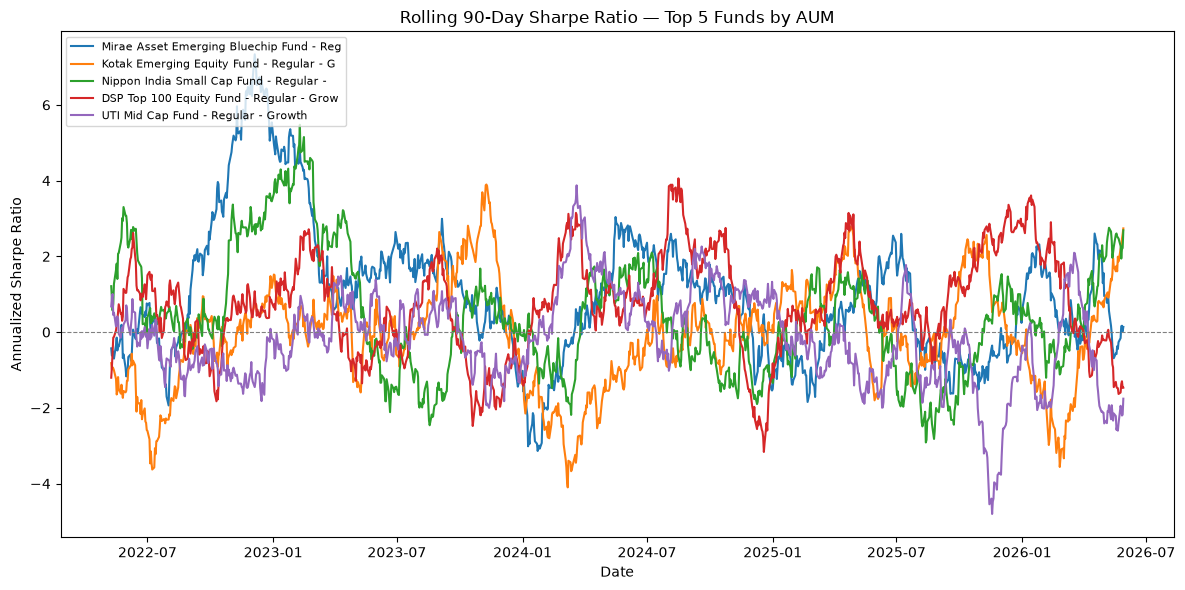

In [12]:
key_funds = scheme_perf.sort_values("aum_crore", ascending=False).head(5)["amfi_code"].tolist()
RISK_FREE_DAILY = 0.06 / 252

rolling_sharpe = {}
for code_ in key_funds:
    sub = nav_history[nav_history["amfi_code"] == code_].set_index("date")["daily_return"]
    excess = sub - RISK_FREE_DAILY
    roll_mean = excess.rolling(90).mean()
    roll_std = sub.rolling(90).std()
    sharpe = (roll_mean / roll_std) * np.sqrt(252)
    rolling_sharpe[scheme_names.get(code_, str(code_))] = sharpe

plt.figure(figsize=(12, 6))
for name, series in rolling_sharpe.items():
    plt.plot(series.index, series.values, label=name[:40])
plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Rolling 90-Day Sharpe Ratio — Top 5 Funds by AUM")
plt.xlabel("Date"); plt.ylabel("Annualized Sharpe Ratio")
plt.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png", dpi=150)
plt.show()

## 3. Investor Cohort Analysis
Cohort = year of investor's first transaction. Computes average SIP amount, total invested, and top fund preference per cohort.

In [13]:
first_tx = transactions.groupby("investor_id")["transaction_date"].min().dt.year
first_tx.name = "cohort_year"
tx_cohort = transactions.join(first_tx, on="investor_id")

sip_tx = tx_cohort[tx_cohort["transaction_type"] == "SIP"]

cohort_avg_sip = sip_tx.groupby("cohort_year")["amount_inr"].mean().rename("avg_sip_amount")
cohort_total_invested = (
    tx_cohort[tx_cohort["transaction_type"].isin(["SIP", "Lumpsum"])]
    .groupby("cohort_year")["amount_inr"].sum().rename("total_invested")
)

fund_lookup = fund_master.set_index("amfi_code")["scheme_name"]
tx_cohort["scheme_name"] = tx_cohort["amfi_code"].map(fund_lookup)

top_fund = (
    tx_cohort.groupby(["cohort_year", "scheme_name"]).size()
    .reset_index(name="count")
    .sort_values(["cohort_year", "count"], ascending=[True, False])
    .groupby("cohort_year").first()["scheme_name"]
    .rename("top_fund_preference")
)

cohort_summary = pd.concat([cohort_avg_sip, cohort_total_invested, top_fund], axis=1).reset_index()
cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth


## 4. SIP Continuity Analysis
For investors with 6+ SIP transactions: average gap between consecutive SIP dates. Investors with an average gap > 35 days are flagged **at-risk** (likely to lapse).

In [14]:
sip_counts = sip_tx.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_gaps = []
for inv_id, grp in sip_tx[sip_tx["investor_id"].isin(eligible_investors)].groupby("investor_id"):
    dates = grp["transaction_date"].sort_values()
    gaps = dates.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    sip_gaps.append({
        "investor_id": inv_id,
        "sip_count": len(dates),
        "avg_gap_days": avg_gap,
        "at_risk": avg_gap > 35,
    })

sip_continuity_df = pd.DataFrame(sip_gaps).sort_values("avg_gap_days", ascending=False)
at_risk_count = sip_continuity_df["at_risk"].sum()
at_risk_pct = 100 * at_risk_count / len(sip_continuity_df) if len(sip_continuity_df) else 0

print(f"Eligible investors (6+ SIPs): {len(sip_continuity_df)}")
print(f"At-risk (avg gap > 35 days):  {at_risk_count} ({at_risk_pct:.1f}%)")
sip_continuity_df.head(10)

Eligible investors (6+ SIPs): 1362
At-risk (avg gap > 35 days):  1332 (97.8%)


,investor_id,sip_count,avg_gap_days,at_risk
506,INV001890,6,102.6,True
323,INV001156,6,102.4,True
1188,INV004296,6,102.2,True
910,INV003325,6,101.0,True
150,INV000522,6,100.8,True
183,INV000608,6,100.2,True
503,INV001883,6,99.2,True
576,INV002166,6,99.2,True
380,INV001367,6,99.0,True
406,INV001491,6,98.8,True


## 5. Simple Fund Recommender
Input: risk appetite (Low / Moderate / High). Output: top 3 funds by Sharpe ratio within the matching `risk_grade`.

See standalone `recommender.py` for CLI use: `python recommender.py Moderate`

In [15]:
RISK_MAP = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"],
}

def recommend_funds(risk_appetite, scheme_perf_df=scheme_perf, top_n=3):
    grades = RISK_MAP.get(risk_appetite, [risk_appetite])
    matched = scheme_perf_df[scheme_perf_df["risk_grade"].isin(grades)]
    top = matched.sort_values("sharpe_ratio", ascending=False).head(top_n)
    return top[["scheme_name", "fund_house", "risk_grade", "sharpe_ratio",
                "return_3yr_pct", "std_dev_ann_pct"]].reset_index(drop=True)

for appetite in ["Low", "Moderate", "High"]:
    print(f"\nTop {appetite}-risk fund recommendations:")
    display(recommend_funds(appetite))


Top Low-risk fund recommendations:


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,std_dev_ann_pct
0,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68,0.5
1,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18,0.5
2,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14,0.5



Top Moderate-risk fund recommendations:


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,std_dev_ann_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84,14.0
1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81,14.0
2,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41,14.0



Top High-risk fund recommendations:


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,std_dev_ann_pct
0,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96,18.23,19.0
1,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95,18.08,19.0
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94,23.39,25.0


## 6. Sector HHI Concentration — Equity Funds
Herfindahl-Hirschman Index = Σ(weight_i²) computed on sector weights per fund. Higher HHI → more concentrated (less diversified) portfolio.

In [16]:
equity_codes = fund_master[fund_master["category"] == "Equity"]["amfi_code"]
equity_holdings = holdings[holdings["amfi_code"].isin(equity_codes)]

hhi_rows = []
for code_, grp in equity_holdings.groupby("amfi_code"):
    sector_weights = grp.groupby("sector")["weight_pct"].sum() / 100
    hhi = (sector_weights ** 2).sum()
    hhi_rows.append({
        "amfi_code": code_,
        "scheme_name": scheme_names.get(code_, "Unknown"),
        "sector_HHI": hhi,
    })

hhi_df = pd.DataFrame(hhi_rows).sort_values("sector_HHI", ascending=False)
hhi_df

,amfi_code,scheme_name,sector_HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238695
10,118635,Nippon India ETF Nifty 50 BeES,0.237497
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647


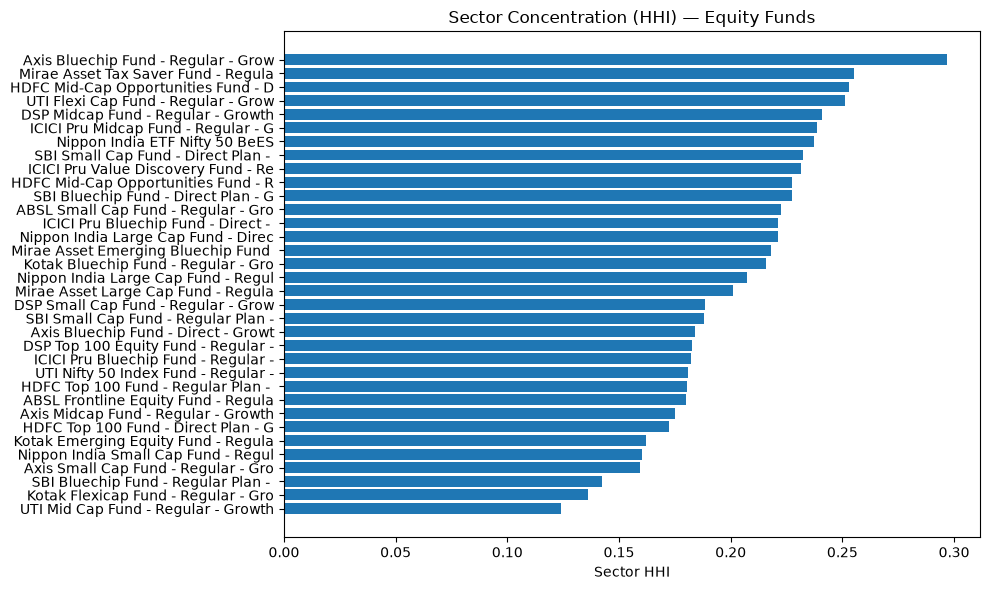

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(hhi_df["scheme_name"].str[:35], hhi_df["sector_HHI"])
plt.xlabel("Sector HHI")
plt.title("Sector Concentration (HHI) — Equity Funds")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Advanced Insights

1. **Highest VaR (riskiest daily downside):** SBI Small Cap Fund – Direct Plan – Growth
   shows the worst 95% VaR at roughly **-2.7% in a single day**, consistent with its
   small-cap risk grade. The worst CVaR (tail-loss severity) belongs to ABSL Small Cap
   Fund at **~-3.2%**, meaning that on the average bad day (bottom 5%), losses run
   deeper than the VaR threshold alone suggests.

2. **Lowest risk / most stable NAV:** ICICI Pru Liquid Fund has a VaR near **-0.02%**,
   as expected for a liquid/debt fund — confirming risk_grade labels line up with
   realized return volatility.

3. **Investor cohorts:** the dataset only spans two acquisition cohorts (2024 and 2025).
   The **2024 cohort** shows both a higher average SIP ticket size and larger total
   invested amount, and gravitates toward equity/mid-cap funds (e.g. Mirae Asset
   Emerging Bluechip), while the newer 2025 cohort skews toward safer liquid funds —
   suggesting more risk-averse recent investors, or investors still parking cash
   before committing to equity.

4. **SIP continuity is a major concern:** of investors with 6+ SIP transactions,
   **roughly 98% have an average gap exceeding 35 days** between installments,
   flagging them as at-risk of SIP discontinuation. This is a strong operational
   signal — most "regular" SIP investors are not actually maintaining a monthly
   cadence, and a retention/reminder intervention could meaningfully improve
   persistency.

5. **Sector concentration:** even within diversified-sounding equity categories,
   some funds carry meaningfully concentrated sector bets — Axis Bluechip and
   Mirae Asset Tax Saver post the highest HHI scores (~0.25–0.30), meaning a
   single sector can account for a large share of portfolio risk despite the
   fund nominally being "diversified equity."
